Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)
import joblib

Load Dataset

In [2]:
df = pd.read_csv("../datasets/healthcare-dataset-stroke-data.csv")

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df = df.drop_duplicates()
df.shape
df = df.drop_duplicates()
print(df.shape)
df["stroke"].value_counts()
df = df.drop("id", axis=1)
print(df.columns)

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB
(5110, 12)
Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status

Basic EDA

In [3]:
df.shape

(5110, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [5]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [6]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Fill Value

In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

Remove Duplicate Data

In [10]:
df = df.drop_duplicates()

print(df.shape)

(5110, 12)


In [11]:
print(df.columns)

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')


In [12]:
df = df.drop("id", axis=1)

In [13]:
print(df.columns)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')


In [43]:
print(df["smoking_status"].unique())

<StringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str


Detailed EDA

Target Distribution

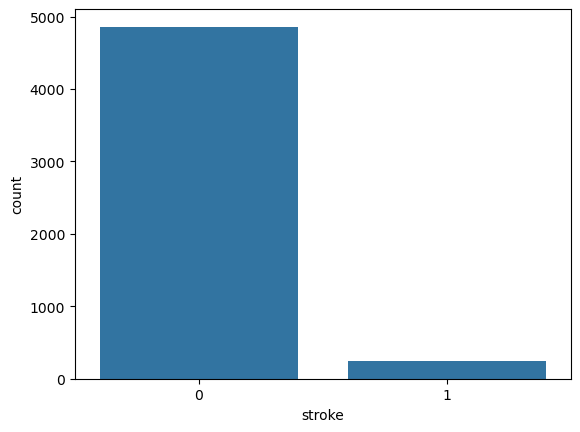

In [14]:
sns.countplot(x="stroke", data=df)
plt.show()

Univariate Analysis (Numerical Features)

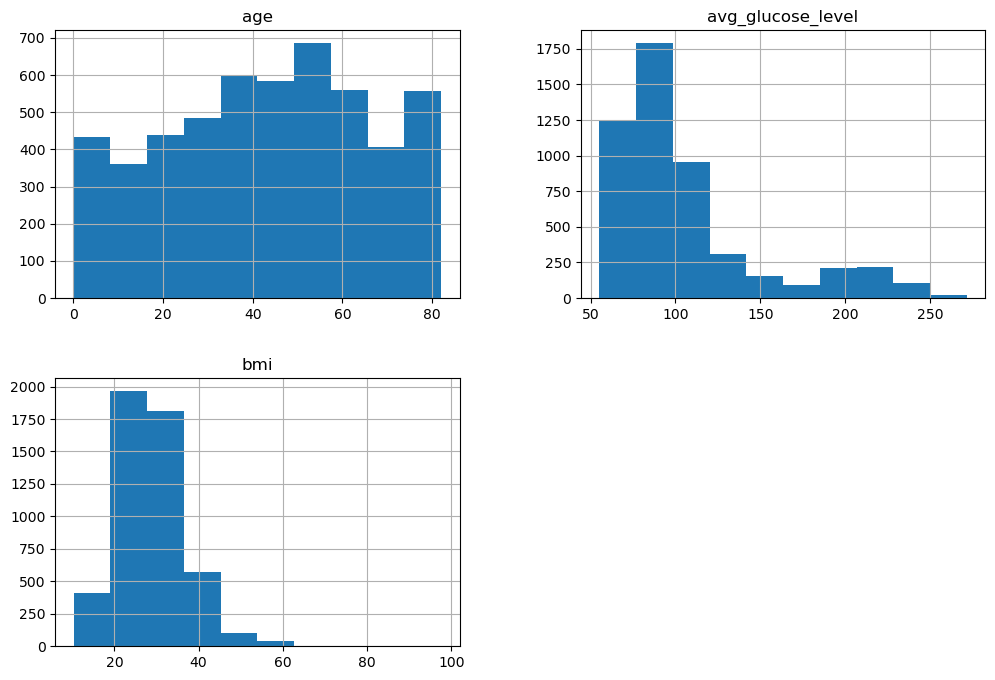

In [15]:
num_cols = [
    "age",
    "avg_glucose_level",
    "bmi"
]

df[num_cols].hist(figsize=(12,8))
plt.show()

Univariate Analysis (Categorical Features)

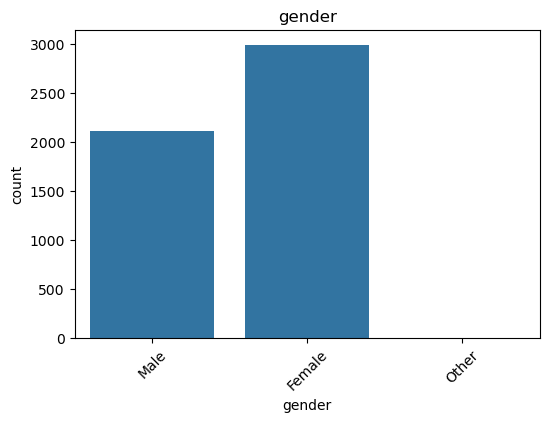

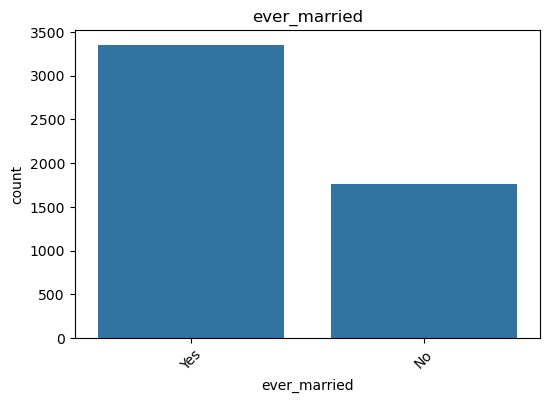

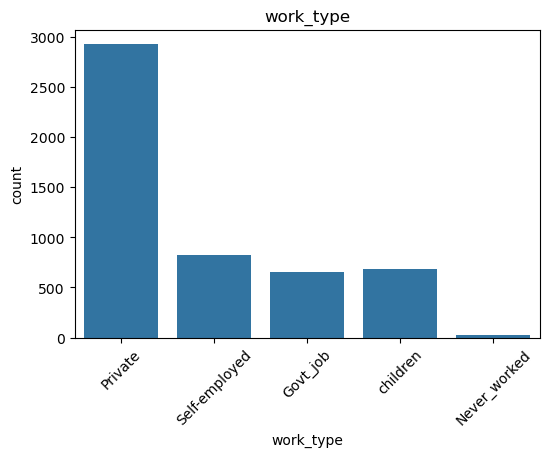

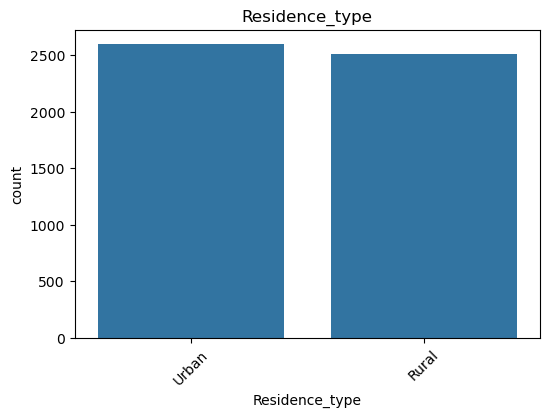

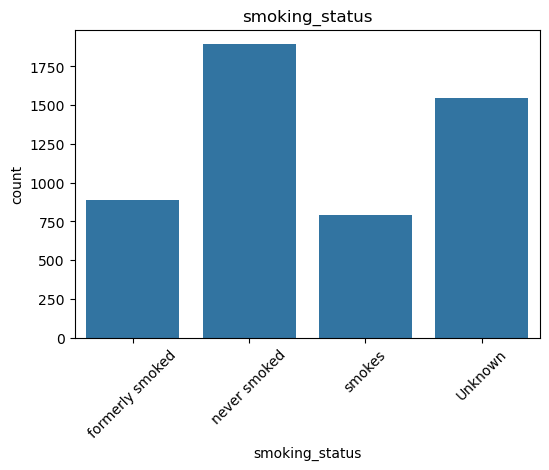

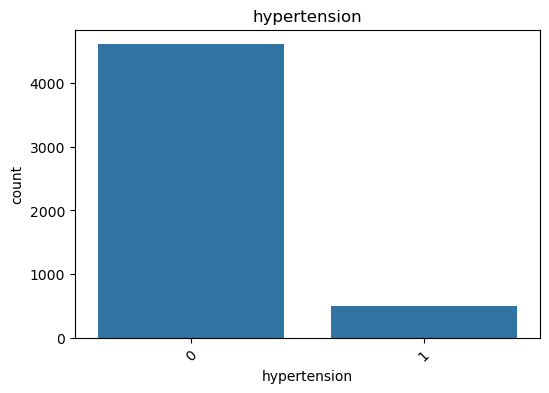

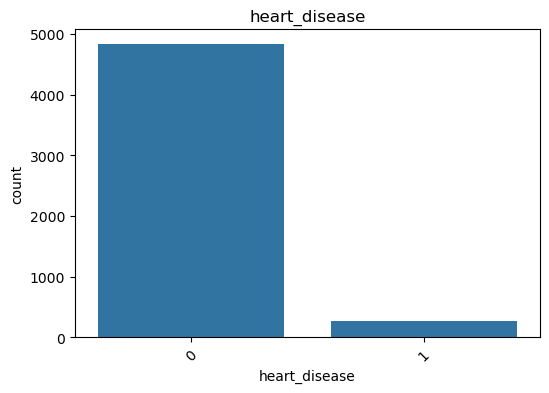

In [16]:
cat_cols = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status",
    "hypertension",
    "heart_disease"
]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

Correlation Heatmap

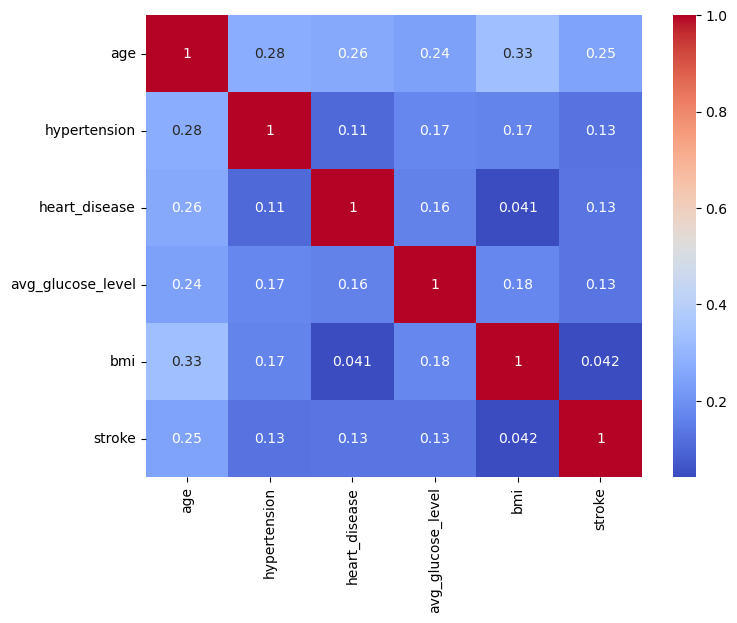

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Outlier Detection

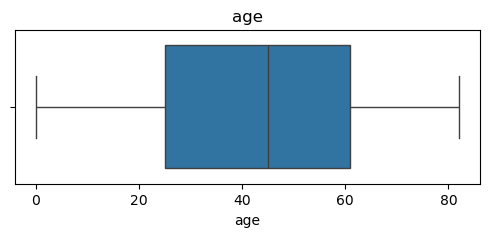

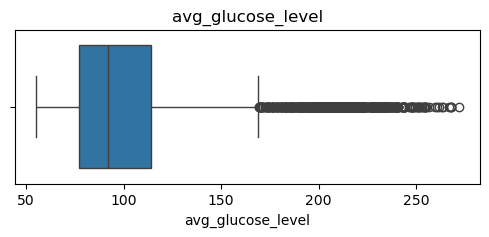

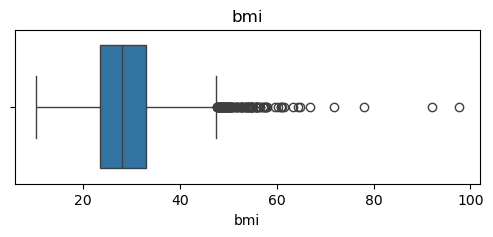

In [18]:
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Feature vs Target Analysis (Numerical)

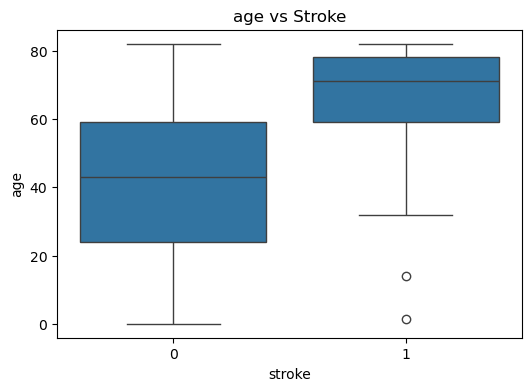

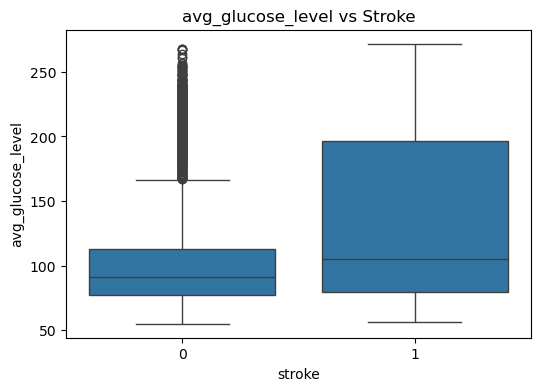

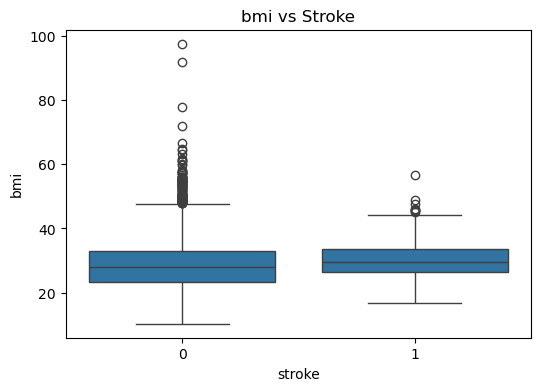

In [19]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="stroke", y=col, data=df)
    plt.title(f"{col} vs Stroke")
    plt.show()

Feature vs Target Analysis (Categorical)

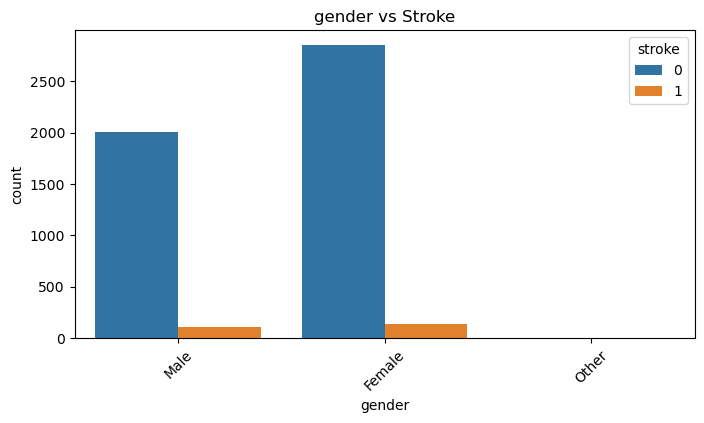

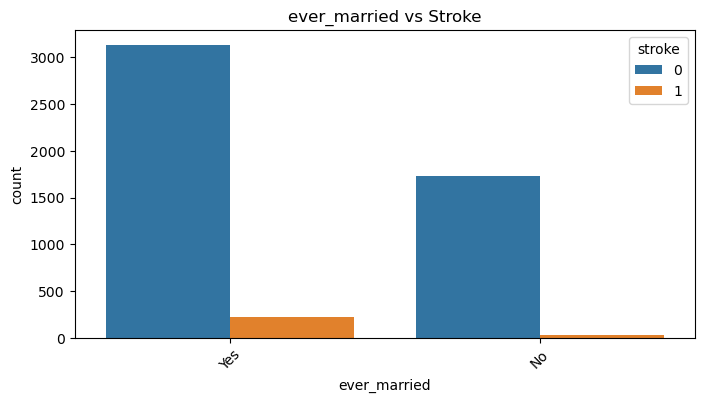

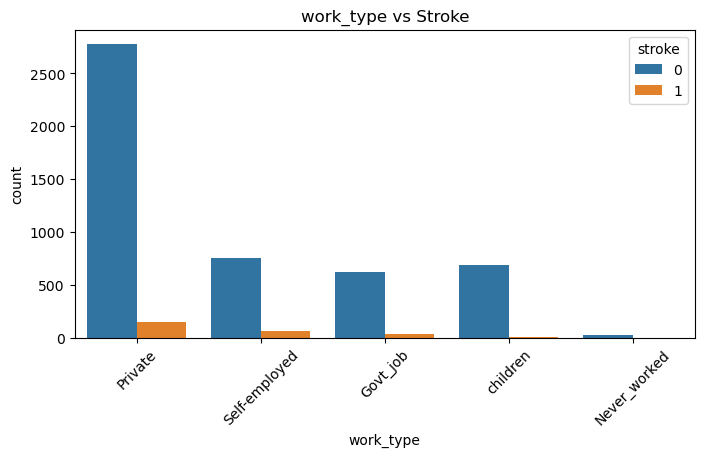

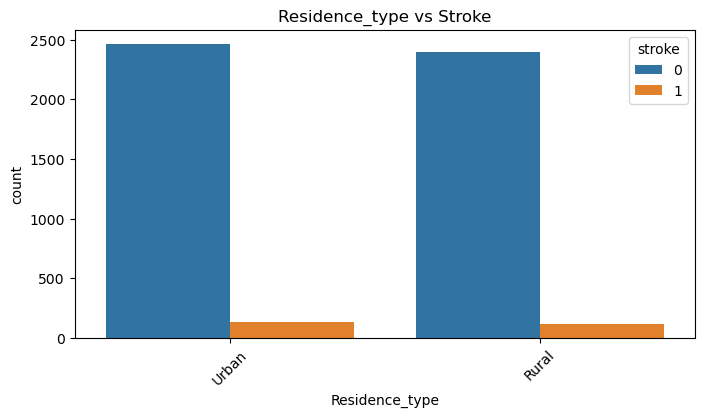

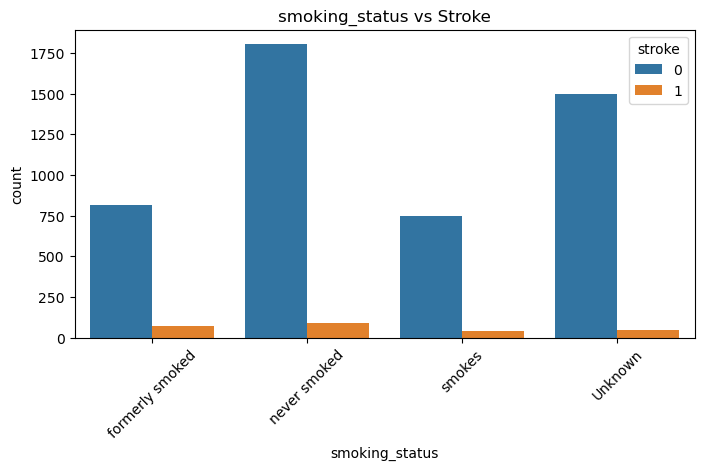

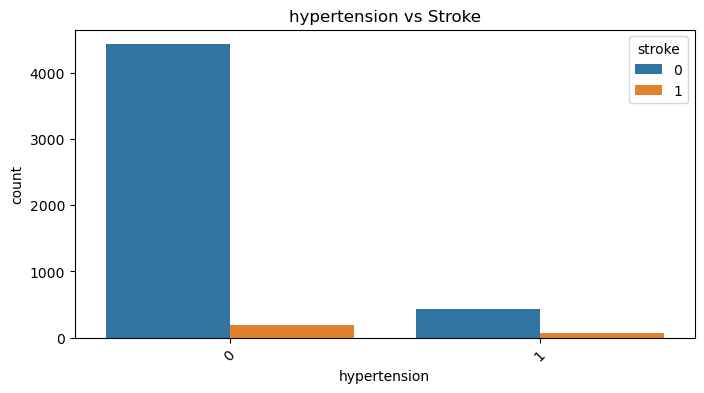

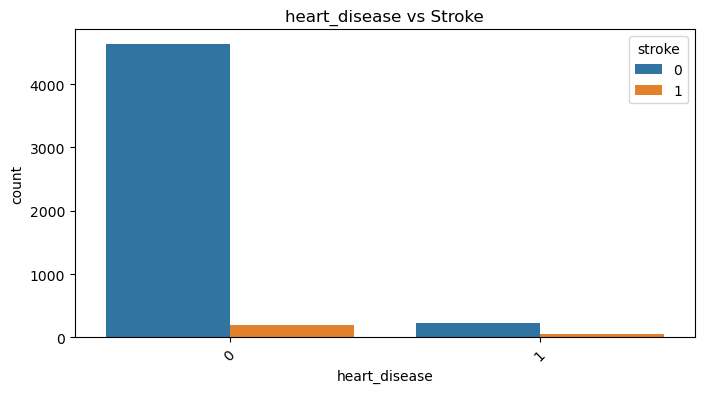

In [20]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue="stroke", data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Stroke")
    plt.show()

In [21]:
df["age_group"] = pd.cut(

    df["age"],

    bins=[0,30,50,65,100],

    labels=["Young","Middle","Senior","Old"]

)

df["bmi_category"] = pd.cut(

    df["bmi"],

    bins=[0,18.5,25,30,100],

    labels=[

        "Underweight",

        "Normal",

        "Overweight",

        "Obese"

    ]

)

Separate Features and Target

In [22]:
X = df.drop("stroke", axis=1)
y = df["stroke"]

Train Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Find Numerical,Categorical & Binary Columns

In [24]:
num_features = [
    "age",
    "avg_glucose_level",
    "bmi"
]

In [25]:
cat_features = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status",
    "age_group",
    "bmi_category"

]

In [26]:
binary_features = [
    "hypertension",
    "heart_disease"
]

Preprocessing Pipeline

In [ ]:
numeric_transformer = Pipeline(

    steps=[

        ("imputer",SimpleImputer(strategy="median")),

        ("scaler",StandardScaler())
    ]
)

In [28]:
categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
        ("bin", "passthrough", binary_features)
    ]
)

Transform Data

In [30]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(4088, 30)
(1022, 30)


Handle Class Imbalance

In [31]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

Create Model Dictionary

In [32]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        C=0.5,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=12,
        class_weight="balanced",
        random_state=42
    ),

    "KNN": KNeighborsClassifier(),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=19,
        random_state=42,
        eval_metric="logloss"
    )
}

Train Every Model

In [33]:
results = []

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test_processed)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_processed)[:,1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = None

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc
    })

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training KNN...
Training XGBoost...


Compare Models

In [34]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.738748,0.134680,0.80,0.230548,0.842016
4,XGBoost,0.712329,0.116352,0.74,0.201087,0.812778
2,Random Forest,0.916830,0.213115,0.26,0.234234,0.811677
3,KNN,0.831703,0.132530,0.44,0.203704,0.705267
1,Decision Tree,0.883562,0.094118,0.16,0.118519,0.540391


Select Best Model

In [35]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Logistic Regression


Check Overfitting

In [36]:
train_pred = models[best_model_name].predict(X_train_processed)
test_pred = models[best_model_name].predict(X_test_processed)

print("Train Accuracy :", accuracy_score(y_train, train_pred))
print("Test Accuracy  :", accuracy_score(y_test, test_pred))

Train Accuracy : 0.7306751467710372
Test Accuracy  : 0.738747553816047


Classification Report

In [37]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
           1       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022



Confusion Matrix

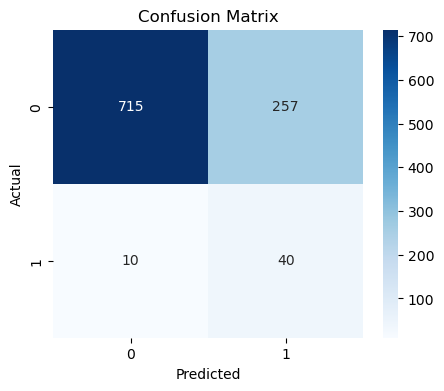

In [38]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Save Best Model

In [39]:
joblib.dump(
    models[best_model_name],
    "../models/stroke_model.pkl"
)

joblib.dump(
    preprocessor,
    "../models/stroke_preprocessor.pkl"
)

['../models/stroke_preprocessor.pkl']